# TissueNarrator — ovarian (Visium-HD) tutorial

Reproduces the ovarian (Visium-HD) figures from TissueNarrator-generated cells:

1. **Marker AUC** — do TN-generated cells express each immune cell type's markers?
2. **Malignant-niche DEG + GSEA** — for Monocytes and CD8 T cells, what changes in
   high- vs low-malignancy neighborhoods (volcano + Reactome lollipop).
3. **In-situ cell-type map**.

This is a TN-only tutorial (no baselines). TN predictions come from saved per-cell-type
inference (`generated_block`); we reconstruct expression and run the downstream analyses.
All inputs are in `tutorials/data/` — see `tutorials/data/README.md`.

> **Note.** Training TissueNarrator and running full inference take **days** on a GPU, so
> this notebook reconstructs the figures from saved per-cell-type predictions
> (`generated_block`) rather than training/inferring from scratch. See
> [`01_preprocess`](01_preprocess.ipynb), [`02_train`](02_train.ipynb), and
> [`03_demo_inference`](03_demo_inference.ipynb) for end-to-end training and inference.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))
import tutorial_utils as tu
from tutorial_utils import data_path

tu.setup_style()

# Ovarian reconstruction fit (log10 rank -> log expression) — dataset-specific.
RECON_SLOPE, RECON_INTERCEPT = -0.758507068795513, 3.9996023408082015
print("ready")

ready


## 1 · Reconstruct TN-generated cells

Per-cell-type generated cells are reconstructed into an expression AnnData. We also derive
the high- vs low-malignancy split (`above_median`) used in section 3 directly from the
data: within each immune lineage (TNK subtypes collapsed), a cell is flagged if its
neighborhood's malignant-cell count (`n_malignant`) exceeds that lineage's median.

In [2]:
df = pd.read_parquet(data_path("ovarian_generation.parquet"))
print(df.shape, "| cell types:", df["center_type"].nunique())

# high- vs low-malignancy split, computed per immune lineage (TNK subtypes collapsed):
# above_median = neighborhood malignant-cell count above the lineage median.
def broad_label(ct):
    if str(ct).startswith("TNK.cell (CD4"):
        return "CD4"
    return {"TNK.cell (CD8.T.cell)": "CD8", "TNK.cell (NK.cell)": "NK",
            "TNK.cell (Treg)": "Treg"}.get(ct, ct)
df["above_median"] = (df.groupby(df["center_type"].map(broad_label))["n_malignant"]
                        .transform(lambda x: x > x.median()))
print("above_median:", df["above_median"].value_counts().to_dict())
print("\nexample generated_block:", df["generated_block"].iloc[0][:110])
print("example answer       :", df["answer"].iloc[0][:110])

adata = sc.read_h5ad(data_path("ovarian_preprocessed.h5ad"))
adata_test = adata[df["center_cell"].tolist()].copy()
vocabulary = tu.generate_vocabulary(adata_test)

obs = pd.DataFrame({"cell_type": df["center_type"].values,
                    "above_median": df["above_median"].values},
                   index=df["center_cell"].values)
generated_adata = tu.build_generated_adata(tu.blocks_to_gene_strings(df["generated_block"]),
                                           obs, adata_test, vocabulary, RECON_SLOPE, RECON_INTERCEPT)
generated_adata.obs["above_median"] = pd.Categorical(generated_adata.obs["above_median"])
generated_adata

(4472, 7) | cell types: 7
above_median: {False: 2513, True: 1959}

example generated_block: <cs>MALAT1 MZT2A IGKC IGHG1 IGHA1 IGHG2 HLA-B XBP1 B2M HLA-DRA HLA-DPA1 HLA-DQA1 HLA-DRB1 HLA-A CD74 HLA-DQB1 
example answer       : <pos> X: 196, Y: 434 <meta> cell_type: B.cell <cs> IGHG1 IGHG2 MALAT1 IGHM RGS1 AZU1 IGFBP7 XBP1 NEAT1 TNFRSF1


  0%|                                                                                                                          | 0/4472 [00:00<?, ?it/s]

  4%|████▏                                                                                                         | 171/4472 [00:00<00:02, 1708.51it/s]

  8%|████████▍                                                                                                     | 343/4472 [00:00<00:02, 1710.52it/s]

 12%|████████████▋                                                                                                 | 515/4472 [00:00<00:02, 1697.26it/s]

...

 90%|██████████████████████████████████████████████████████████████████████████████████████████████████▏          | 4030/4472 [00:02<00:00, 1750.34it/s]

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌      | 4209/4472 [00:02<00:00, 1761.02it/s]

 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 4386/4472 [00:02<00:00, 1731.13it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4472/4472 [00:02<00:00, 1729.00it/s]

AnnData object with n_obs × n_vars = 4472 × 979
    obs: 'cell_type', 'above_median'

## 2 · Marker AUC

For each immune cell type, how well do the TN-generated cells of that type separate
from the rest by their canonical markers (mean AUROC over markers)?

In [3]:
marker_dict = {
    "B.cell": ["CD27","CD38","CD79A","DUSP5","FKBP11","IGHA1","IGHG1","IGHG2","IGHM","IGKC",
               "IRF4","JCHAIN","LPAR5","MZB1","ST6GAL1","XBP1"],
    "Monocyte": ["AXL","C1QA","C1QB","C1QC","CCL2","CCR1","CD14","CD163","CD300A","CD4","CD68",
                 "CD74","CFD","CIITA","CLEC7A","CMKLR1","CSF1R","CSF2RA","CSF3R","CXCL16","CXCL9",
                 "FCER1G","FCGBP","FCGR3A","FGR","FPR1","GLUL","GPNMB","GPR183","GPX1","HAVCR2","HCK",
                 "HLA-DPA1","HLA-DPB1","HLA-DQA1","HLA-DQB1","HLA-DRA","HLA-DRB1","HLA-DRB5","IFNGR1",
                 "IL10RA","IL18","ITGAM","ITGAX","ITGB2","LAIR1","LGALS9","LYN","LYZ","MERTK"],
    "TNK.cell (CD4.T.cell)": ["CD4","FOXP3","MAF","CTLA4","IL2RA","TNFRSF4","LTB","TNFRSF18","IL12RB2",
                              "SPOCK2","IL7R","IL6R","ICOS","CD40LG","CD28","SELL","TNFRSF1B","S100A4","RORA","LYZ"],
    "TNK.cell (CD8.T.cell)": ["CD8A","CCL5","KLRK1","CD8B","NKG7","CCL4","GZMH","ITGAE","GZMA","CTSW",
                              "ITGA1","CCL4L2","GZMB","GZMK","CST7","PRF1","LAG3","CCL3","LINC02446","FASLG"],
    "TNK.cell (NK.cell)": ["GNLY","XCL2","NKG7","CST3","SPINK2","HMOX1","MALAT1","IGFBP4","HBG2","STMN1","KLHL23","NCAM1"],
    "TNK.cell (Treg)": ["FOXP3","TNFRSF21","HLA-DQA1","IL2RA","TM4SF1","BAX","IL27RA","COL4A2","ETV5","MRC2",
                        "CLDN4","CD164","CTLA4","IRF4","RARRES2","FLT1","SERPINH1","ITGB8","CALM3","HILPDA"],
}

from sklearn.metrics import roc_auc_score
scores = {}
for ct, markers in marker_dict.items():
    present = [g for g in markers if g in generated_adata.var_names]
    if not present:
        continue
    mask = (generated_adata.obs["cell_type"] == ct).astype(int).values
    if np.unique(mask).size == 1:
        continue
    expr = generated_adata[:, present].X
    expr = expr.toarray() if hasattr(expr, "toarray") else np.asarray(expr)
    scores[ct] = np.mean([roc_auc_score(mask, expr[:, i]) for i in range(len(present))])
df_scores = pd.DataFrame.from_dict(scores, orient="index", columns=["AUC"])
print(df_scores)

                            AUC
B.cell                 0.734722
Monocyte               0.700119
TNK.cell (CD4.T.cell)  0.556891
TNK.cell (CD8.T.cell)  0.665990
TNK.cell (NK.cell)     0.542011
TNK.cell (Treg)        0.542522


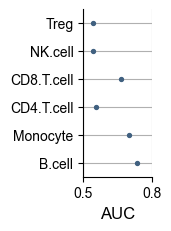

In [4]:
import re
import matplotlib.pyplot as plt

ds = df_scores.copy()
ds.index = ds.index.to_series().apply(lambda x: re.search(r"\(([^)]+)\)", x).group(1) if "(" in x and ")" in x else x)
ds = ds.reset_index().rename(columns={"index": "Cell type"})
fig, ax = plt.subplots(figsize=(1.6, 2.2))
ds.plot.scatter(y="Cell type", x="AUC", ax=ax, color="#406080", s=8)
ax.set_xlabel("AUC", fontsize=12); ax.set_ylabel("")
for pos in ("right", "top"): ax.spines[pos].set_visible(False)
ax.set_ylim([-0.5, len(ds) - 0.5]); ax.set_axisbelow(True); ax.grid(axis="both", zorder=0)
ax.set_xticks([0.5, 0.8])
plt.tight_layout(pad=0.3); plt.show()

## 3 · Malignant-niche DEG + GSEA (Monocyte & CD8)

For a given cell type, compare TN-generated cells in high- vs low-malignancy
neighborhoods (`above_median`), excluding epithelial contamination genes, then show a
volcano and a Reactome GSEA lollipop. The helpers below are reused for both cell types.

In [5]:
import scanpy as sc

EPITHELIAL = ["KRT8","KRT18","KRT19","KRT7","KRT15","KRT17","EPCAM","CD24","TUBB"]

def celltype_deg(gadata, cell_type):
    sub = gadata[gadata.obs["cell_type"] == cell_type].copy()
    keep = np.array((sub.X > 0).sum(axis=0)).flatten() >= 10
    for g in EPITHELIAL:
        if g in sub.var_names:
            keep[sub.var_names.get_loc(g)] = False
    sub = sub[:, keep].copy()
    sc.tl.rank_genes_groups(sub, groupby="above_median", method="wilcoxon",
                            rankby_abs=True, tie_correct=True, key_added="k")
    return sub, sc.get.rank_genes_groups_df(sub, key="k", group="True")

def volcano(deg_df, pos_genes, neg_genes, pval_th=0.001, lfc_min=0.5, lfc_max=10, ylim=60, seed=36):
    import matplotlib.pyplot as plt
    np.random.seed(seed)
    d = deg_df[deg_df["logfoldchanges"].between(-20, 20)].copy()
    d["nlp"] = -np.log10(np.clip(d["pvals_adj"].values, 1e-300, 1.0))
    sig = (d["pvals_adj"] < pval_th) & (d["logfoldchanges"].abs().between(lfc_min, lfc_max))
    up, down, ns = d[sig & (d["logfoldchanges"] >= lfc_min)], d[sig & (d["logfoldchanges"] <= -lfc_min)], d[~sig]
    plt.figure(figsize=(5, 4.2))
    plt.scatter(ns["logfoldchanges"], ns["nlp"], s=10, alpha=0.6, color="grey", label="Not significant", zorder=1)
    plt.scatter(down["logfoldchanges"], down["nlp"], s=10, alpha=0.6, color="blue", label="Down-regulated", zorder=2)
    plt.scatter(up["logfoldchanges"], up["nlp"], s=10, alpha=0.6, color="red", label="Up-regulated", zorder=2)
    plt.ylim(0, ylim)
    for _, r in d[d["names"].isin(pos_genes + neg_genes)].iterrows():
        dx = np.random.choice([-1, 1]) * np.random.uniform(0.3, 0.5)
        plt.annotate(r["names"], xy=(r["logfoldchanges"], r["nlp"]),
                     xytext=(r["logfoldchanges"] + dx, r["nlp"] + np.random.uniform(1, 1.2)),
                     fontsize=15, ha="center",
                     arrowprops=dict(arrowstyle="-", color="black", lw=0.5, shrinkA=0, shrinkB=0))
    plt.axvline(-lfc_min, color="grey", ls="--"); plt.axvline(lfc_min, color="grey", ls="--")
    plt.axhline(-np.log10(pval_th), color="grey", ls="--")
    plt.xlim(-6, 6); plt.xlabel("logFC", fontsize=20); plt.ylabel("-logFDR", fontsize=20)
    plt.xticks(fontsize=16); plt.yticks(fontsize=16)
    plt.legend(loc="upper right", markerscale=2, fontsize=15, handletextpad=0.0,
               handlelength=1.5, labelspacing=0.5, borderpad=0.05)
    plt.tight_layout(); plt.show()

def gsea_reactome(result, fdr=0.03):
    import polars as pl, gseapy as gp
    rnk = result[["names", "scores"]].dropna().sort_values("scores", ascending=False).set_index("names")["scores"]
    res = gp.prerank(rnk=rnk, gene_sets=["GO_Biological_Process_2025", "GO_Molecular_Function_2025",
                     "GO_Cellular_Component_2025", "Reactome_Pathways_2024", "KEGG_2021_Human"],
                     organism="Human", outdir=None)
    g = (pl.DataFrame(res.res2d).filter(pl.col("FDR q-val") < fdr)
         .with_columns(pl.col("Term").map_elements(lambda x: x.split("__")[0], return_dtype=str).alias("gene_set"),
                       pl.col("Term").map_elements(lambda x: x.split("__")[1], return_dtype=str).alias("pathway")))
    return g.filter(pl.col("gene_set") == "Reactome_Pathways_2024").sort("FDR q-val").to_dicts()

def reactome_lollipop(gsea_reactome, top_n=8, order_by="RichFactor"):
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.cm import ScalarMappable
    d = pd.DataFrame(gsea_reactome).copy()
    nd = d["Tag %"].str.split("/", expand=True).astype(float)
    d["Count"], d["SetSize"] = nd[0].astype(int), nd[1].astype(int)
    d["RichFactor"] = d["Count"] / d["SetSize"]
    p = d["FDR q-val"].replace(0, np.nan).fillna(d["NOM p-val"])
    d["neglog10_p"] = -np.log10(p + 1e-300)
    label = "pathway" if "pathway" in d.columns else "Term"
    d = d.sort_values(order_by, ascending=False).head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(3, 4.5))
    y, x = np.arange(len(d)), d["NES"].to_numpy()
    for i, xi in enumerate(x):
        ax.hlines(y=i, xmin=0, xmax=xi, lw=1.2, color="0.85")
    cmap = LinearSegmentedColormap.from_list("custom", ["#3C8DAD", "white", "#FF6767"], N=256)
    norm = Normalize(vmin=d["neglog10_p"].min(), vmax=d["neglog10_p"].max())
    sizes = np.interp(d["Count"], (d["Count"].min(), d["Count"].max()), (30, 120))
    ax.scatter(x, y, s=sizes, c=d["neglog10_p"], cmap=cmap, norm=norm, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(d[label]); ax.set_xlabel("NES", fontsize=18); ax.set_ylabel("")
    ax.grid(False)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_linewidth(1.0); ax.spines[s].set_color("black")
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label("-log10(p.adjust)", fontsize=18); cbar.ax.tick_params(labelsize=16)
    plt.xlim(-3, 3); plt.xticks(fontsize=17); plt.yticks(fontsize=17); plt.tight_layout(); plt.show()
print("helpers ready")

helpers ready


### Monocyte — high vs low malignancy

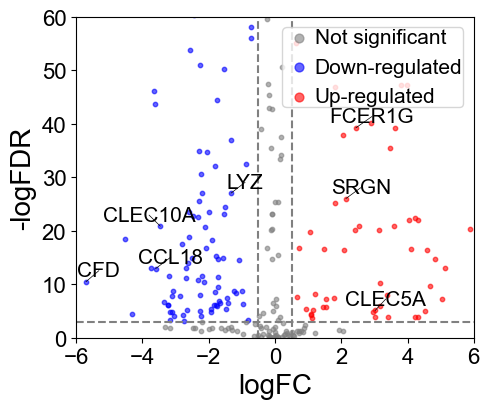

/tmp/ipykernel_1256790/3293375113.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.xlim(-3, 3); plt.xticks(fontsize=17); plt.yticks(fontsize=17); plt.tight_layout(); plt.show()


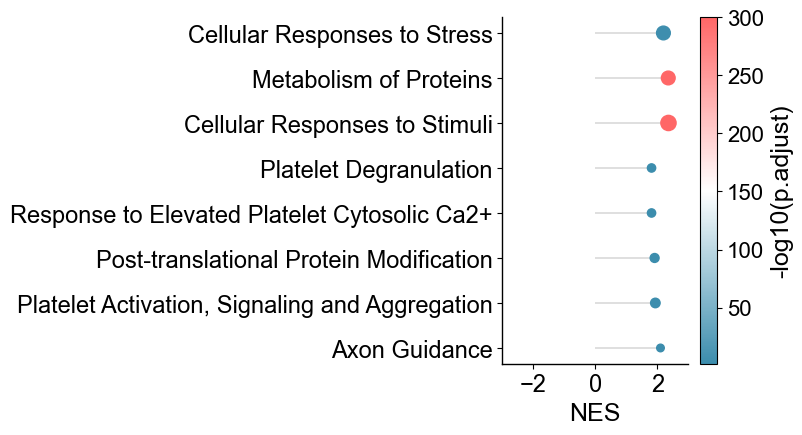

In [6]:
mono_adata, mono_deg = celltype_deg(generated_adata, "Monocyte")
volcano(mono_deg, pos_genes=["CLEC5A", "FCER1G", "SPP1", "SRGN"],
        neg_genes=["CLEC10A", "CCL18", "CFD", "IL2RA", "LYZ"])
reactome_lollipop(gsea_reactome(mono_deg), top_n=8, order_by="RichFactor")

### CD8 T cell — high vs low malignancy

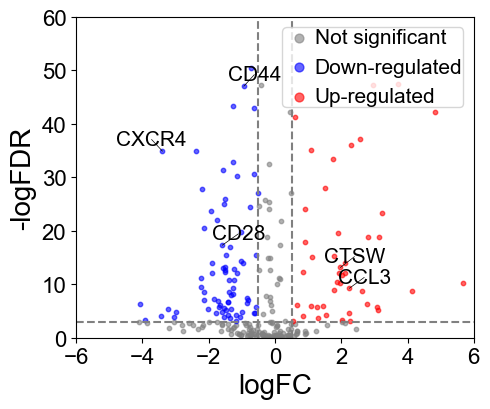

/tmp/ipykernel_1256790/3293375113.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.xlim(-3, 3); plt.xticks(fontsize=17); plt.yticks(fontsize=17); plt.tight_layout(); plt.show()


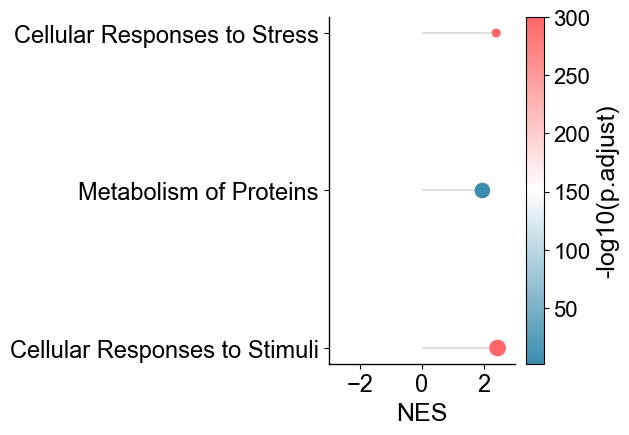

In [7]:
cd8_adata, cd8_deg = celltype_deg(generated_adata, "TNK.cell (CD8.T.cell)")
volcano(cd8_deg, pos_genes=["CCL3", "CTSW"], neg_genes=["CXCR4", "CD28", "CD44"])
reactome_lollipop(gsea_reactome(cd8_deg), top_n=8, order_by="RichFactor")

## 4 · In-situ cell-type map

Spatial map of cell groups for one section (TNK subtypes collapsed).

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


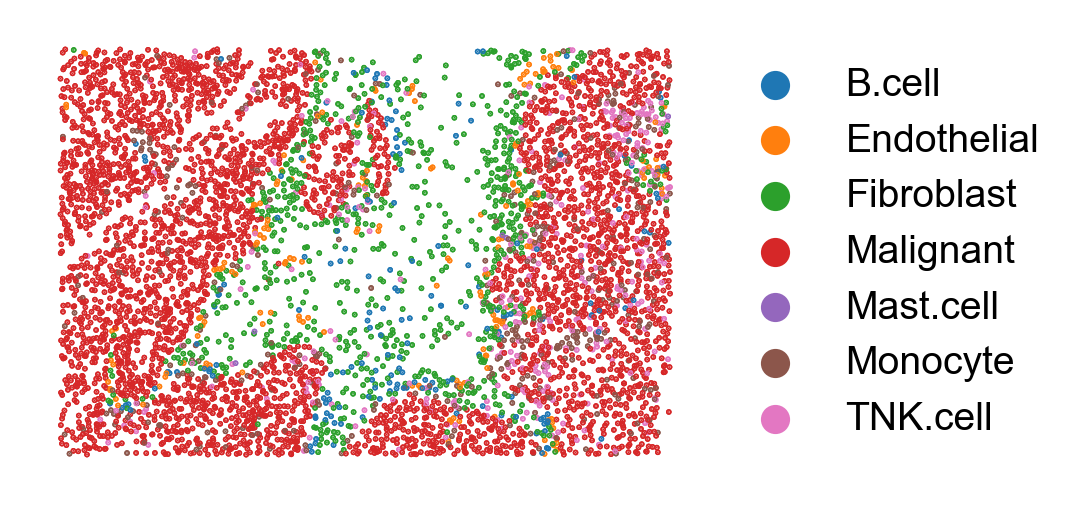

In [8]:
import squidpy as sq
import matplotlib.pyplot as plt

adata.obs["cell_group"] = adata.obs["cell_type"].map(
    lambda c: "TNK.cell" if str(c).startswith("TNK.cell") else c)
adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()
asec = adata[adata.obs["section"] == "SMI_T10_F001"].copy()
sq.pl.spatial_scatter(asec, color=["cell_group"], dpi=300, legend_loc="right margin", shape=None,
                      figsize=(3.5, 3.5), size=.5, legend_fontsize=9.4, cmap="Reds", ncols=3,
                      colorbar=False, vmin=0., wspace=.0, outline=False, frameon=False, title="")
plt.show()